In [1]:
from google.colab import files
uploaded = files.upload()


Saving loan_prediction.csv to loan_prediction.csv


In [2]:
import pandas as pd

df = pd.read_csv("loan_prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Optional XGBoost
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load dataset
df = pd.read_csv("loan_prediction.csv")

# Preview
print(df.head())

# Dataset info
print(df.info())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [5]:
# Check missing values
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [6]:
target = "Loan_Status"

In [7]:
# Encode target variable
df[target] = df[target].map({'Y': 1, 'N': 0})

# Features and target
X = df.drop(target, axis=1)
y = df[target]


In [8]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area'],
      dtype='object')
Numerical Columns: Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')


In [9]:
# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(491, 12) (123, 12)


In [11]:
# Transform data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [12]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Loan_Status
1    337
0    154
Name: count, dtype: int64

After SMOTE:
Loan_Status
1    337
0    337
Name: count, dtype: int64


In [13]:
log_model = LogisticRegression()

log_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_log = log_model.predict(X_test_processed)
y_prob_log = log_model.predict_proba(X_test_processed)[:, 1]

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

In [15]:
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

In [16]:
def evaluate_model(y_true, y_pred, y_prob, model_name):

    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    print("Precision :", round(precision, 4))
    print("Recall    :", round(recall, 4))
    print("F1 Score  :", round(f1, 4))
    print("ROC-AUC   :", round(roc_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Logistic Regression
Precision : 0.8632
Recall    : 0.9647
F1 Score  : 0.9111
ROC-AUC   : 0.8687

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.66      0.76        38
           1       0.86      0.96      0.91        85

    accuracy                           0.87       123
   macro avg       0.88      0.81      0.83       123
weighted avg       0.87      0.87      0.86       123



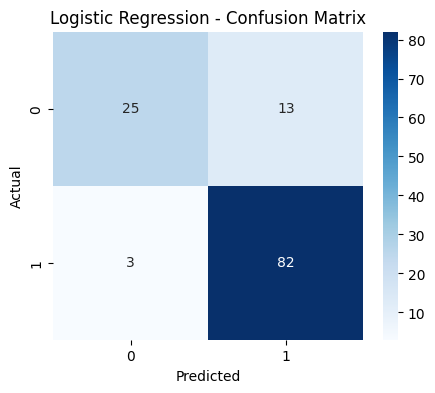


Random Forest
Precision : 0.8384
Recall    : 0.9765
F1 Score  : 0.9022
ROC-AUC   : 0.7955

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.58      0.71        38
           1       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



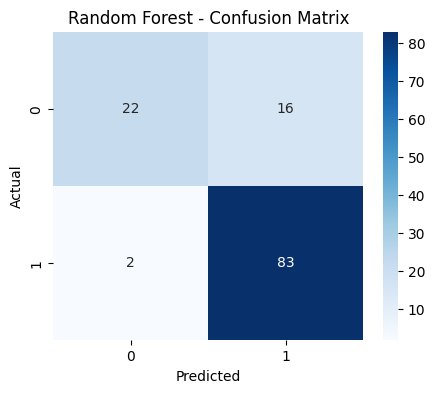


XGBoost
Precision : 0.8427
Recall    : 0.8824
F1 Score  : 0.8621
ROC-AUC   : 0.7845

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.63      0.67        38
           1       0.84      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.76       123
weighted avg       0.80      0.80      0.80       123



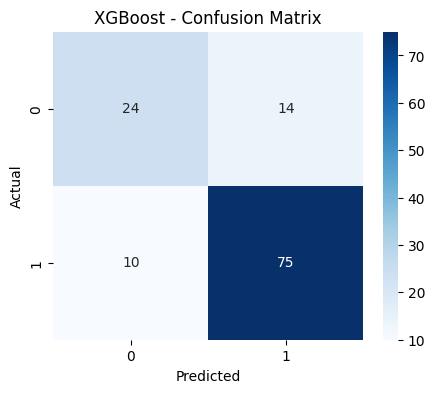

In [17]:
evaluate_model(y_test, y_pred_log, y_prob_log, "Logistic Regression")

evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")

evaluate_model(y_test, y_pred_xgb, y_prob_xgb, "XGBoost")

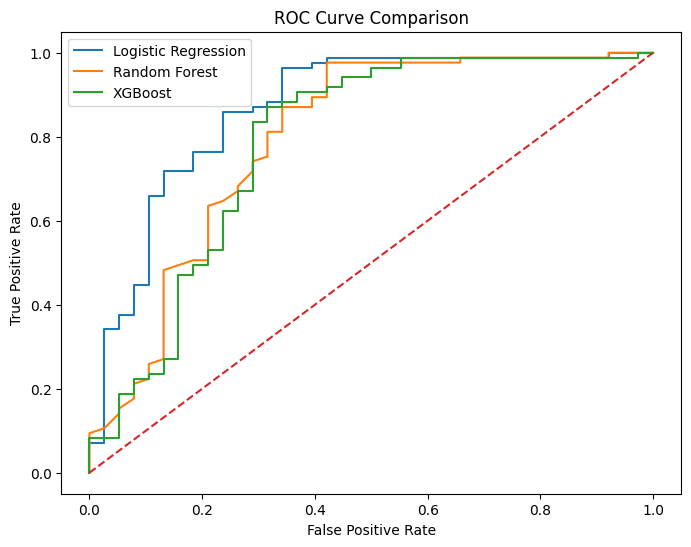

In [18]:
plt.figure(figsize=(8,6))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, label='Logistic Regression')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label='Random Forest')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')

# Random line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

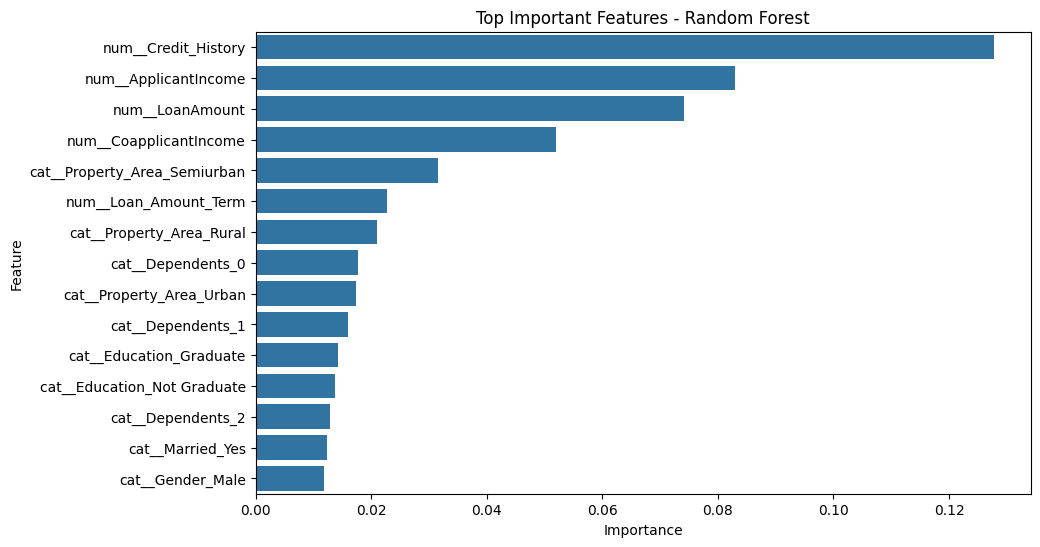

In [19]:
# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(15)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Top Important Features - Random Forest")
plt.show()

In [20]:
threshold = 0.40

y_custom_pred = (y_prob_rf >= threshold).astype(int)

print("Threshold:", threshold)

print(classification_report(y_test, y_custom_pred))

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.89      0.45      0.60        38
           1       0.80      0.98      0.88        85

    accuracy                           0.81       123
   macro avg       0.85      0.71      0.74       123
weighted avg       0.83      0.81      0.79       123



In [21]:
print("""
Business Insights:

1. Applicants with higher income and credit history
   are more likely to receive loan approval.

2. Logistic Regression provides interpretability,
   making it useful for banking compliance.

3. Random Forest/XGBoost generally improve recall
   and ROC-AUC by capturing nonlinear relationships.

4. Lowering prediction threshold increases recall,
   helping reduce rejection of eligible applicants.

5. Recommended deployment threshold:
   0.40–0.45 for balanced recall and precision.
""")


Business Insights:

1. Applicants with higher income and credit history
   are more likely to receive loan approval.

2. Logistic Regression provides interpretability,
   making it useful for banking compliance.

3. Random Forest/XGBoost generally improve recall
   and ROC-AUC by capturing nonlinear relationships.

4. Lowering prediction threshold increases recall,
   helping reduce rejection of eligible applicants.

5. Recommended deployment threshold:
   0.40–0.45 for balanced recall and precision.

